In [4]:
import random
from typing import Union
import joblib
import cloudpickle
import pandas as pd
import numpy as np

from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import mean_squared_error

import pymc as pm
import pymc.sampling.jax as pmjax
import pytensor.tensor as pt
import arviz as az
import arviz_plots as azp
import xarray as xr

import matplotlib.pyplot as plt
RANDOM_SEED = 457775 # https://www.reddit.com/r/baseball/comments/b5vfik/whos_the_most_random_mlb_player_you_can_think_of/
np.random.seed(RANDOM_SEED)

In [5]:
# for reproducibility
print("panda: "+pd.__version__)
print("numpy: "+np.__version__)
print("pymc: "+pm.__version__)
import sklearn
print("sklearn: "+sklearn.__version__)
import pytensor
print("pytensor: "+pytensor.__version__)
print("arviz: "+az.__version__)
print("arviz_plots: "+azp.__version__)

panda: 3.0.1
numpy: 2.4.3
pymc: 5.28.2
sklearn: 1.8.0
pytensor: 2.38.2
arviz: 0.23.4
arviz_plots: 1.0.0


In [6]:
qt_scaler = joblib.load('data/quantile_scaler.pkl')
qt_scaler_cols = ['ev90_qt','bat_speed_qt','imputed_bat_speed_qt']
qt_age = joblib.load('data/quantile_age.pkl')

In [7]:
df = pd.read_csv('data/data.csv')
df['bam_id'] = pd.to_numeric(df['bam_id'], errors='coerce')

In [8]:
def define_index(data: pd.DataFrame, label: str, plus_one:bool=True) -> Union[np.array, dict]:
    """Defines an index variable starting at 1. We add 1 so '0' can act as a placeholder for
    any global optionality
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format

    Returns:
        Union[
            np.array: indexed values
            dict: dictionary mapping the input values and their indexed values
            ]
    """
    unq_ids = data[label].astype(str).unique()
    lookup = {v: i for i, v in enumerate(unq_ids)}
    index_vals = data[label].astype(str).map(lookup).values
    
    if plus_one:
        index_vals = index_vals + 1
    return index_vals, lookup

def sample(
    model: pm.Model,
    draws: int = 2000,
    tune: int = 2000,
    chains: int = 4,
    target_accept: float = 0.99,
    random_seed: int = RANDOM_SEED,
    path:str = 'temp.nc',
    **kwargs
):
    """
    Fit model using MCMC.

    Parameters
    ----------
    model: pm.Model
        PyMC model object.
    draws : int
        Number of draws to keep from the sampling process.
    tune : int
        Number of tuning steps to take before sampling.
    chains : int
        Number of chains to sample.
    target_accept : float
        Target acceptance probability for step size adaptation.
    random_seed : int
        Seed for randomness.
    """
    with model:
        trace = pmjax.sample_numpyro_nuts(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            idata_kwargs={"log_likelihood": False}
        )
    try:
        az.to_netcdf(trace, path)
    except Exception as e:
        print(f"Error saving trace to {path}: {e}")
    return trace

def compute_log_likelihood(model: pm.Model, trace: az.InferenceData) -> None:
    """Wrapper to compute elemwise log_likelihood of model given InferenceData with posterior group
    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling
    """
    with model:
        pm.compute_log_likelihood(trace)
    return None

def sample_posterior_pred(model: pm.Model, trace: az.InferenceData) -> az.InferenceData:
    """Generates samples from the posterior predictive distribution for model checks

    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling

    Returns:
        az.InferenceData: An ArviZ InferenceData object containing the posterior predictive samples.
    """
    with model:
        spp = pm.sample_posterior_predictive(
            trace,
            extend_inferencedata=True,
            random_seed=RANDOM_SEED,
        )
    return spp

In [9]:
# players
df['player_full_id'] = df['full'] + " (" + df['bam_id'].astype(str) + ")"
player_name_list = pd.unique(df['player_full_id']).tolist()
df["player_idx"], player_lookup = define_index(df, "player_full_id", plus_one=False)
player_idx_vals = df['player_idx'].values.astype("int32")

# seasonal and month
time_idx_vals = df['time_index'].values.astype("int32")
df['time_lbl'] = df['year'].astype(str) + "-" + df['month_name'].astype(str)
time_list = df[['time_index', 'time_lbl']].drop_duplicates().sort_values('time_index')['time_lbl'].tolist()

# bats
df['bats_idx'] = df['bats'].map({'R':0,'L':1,'S':2})
bats_list = ['R','L','S']
bats_idx_vals = df['bats_idx'].values

# position, only allow pre-defined positions
df['position_idx'], position_lookup = define_index(df, "position", False)
position_list = pd.unique(df['position']).tolist()
position_idx_vals = df['position_idx'].values

df['position_group_idx'], position_group_lookup = define_index(df, "position_group", False)
position_group_list = pd.unique(df['position_group']).tolist()
position_group_idx_vals = df['position_group_idx'].values

df['position_hybrid_idx'], position_hybrid_lookup = define_index(df, "position_hybrid", False)
position_hybrid_list = pd.unique(df['position_hybrid']).tolist()
position_hybrid_idx_vals = df['position_hybrid_idx'].values

# country index, allow for new countries
df['region_idx'], position_lookup = define_index(df, "region")
region_list = ['New Country'] + pd.unique(df['region']).tolist()
region_idx_vals = df['region_idx'].values

df['country_idx'], position_lookup = define_index(df, "country")
country_list = ['New Country'] + pd.unique(df['country']).tolist()
country_idx_vals = df['country_idx'].values

df['country2_idx'], position_lookup = define_index(df, "country2")
country2_list = ['New Country'] + pd.unique(df['country2']).tolist()
country2_idx_vals = df['country2_idx'].values

In [10]:
df.head(3)

,bam_id,year,month_name,time_index,bips,ev90,ev90_center,ev90_z,ev90_qt,imputed_bat_speed,...,player_full_id,player_idx,time_lbl,bats_idx,position_idx,position_group_idx,position_hybrid_idx,region_idx,country_idx,country2_idx
0,405395,2021,Mar/Apr,0,63.0,106.16,3.538975,0.734768,0.892038,73.103005,...,Albert Pujols (405395),0,2021-Mar/Apr,0,0,0,0,1,1,1
1,405395,2021,May,1,41.0,108.40,5.778975,1.199840,1.588771,75.037366,...,Albert Pujols (405395),0,2021-May,0,0,0,0,1,1,1
2,405395,2021,Jun,2,41.0,103.90,1.278975,0.265543,0.205941,72.504313,...,Albert Pujols (405395),0,2021-Jun,0,0,0,0,1,1,1


In [11]:
df.tail(5)

,bam_id,year,month_name,time_index,bips,ev90,ev90_center,ev90_z,ev90_qt,imputed_bat_speed,...,player_full_id,player_idx,time_lbl,bats_idx,position_idx,position_group_idx,position_hybrid_idx,region_idx,country_idx,country2_idx
34645,823550,2026,May,31,8.0,101.04,-1.581025,-0.328255,-0.596935,68.480975,...,Sung-Mun Song (823550),1177,2026-May,1,7,0,0,8,26,20
34646,823550,2026,Jun,32,NaN,NaN,NaN,NaN,NaN,NaN,...,Sung-Mun Song (823550),1177,2026-Jun,1,7,0,0,8,26,20
34647,823550,2026,Jul,33,NaN,NaN,NaN,NaN,NaN,NaN,...,Sung-Mun Song (823550),1177,2026-Jul,1,7,0,0,8,26,20
34648,823550,2026,Aug,34,NaN,NaN,NaN,NaN,NaN,NaN,...,Sung-Mun Song (823550),1177,2026-Aug,1,7,0,0,8,26,20
34649,823550,2026,Sep/Oct,35,NaN,NaN,NaN,NaN,NaN,NaN,...,Sung-Mun Song (823550),1177,2026-Sep/Oct,1,7,0,0,8,26,20


In [12]:
df = df.loc[(df['time_index']<=33)].reset_index(drop=True)
df.tail(5)

,bam_id,year,month_name,time_index,bips,ev90,ev90_center,ev90_z,ev90_qt,imputed_bat_speed,...,player_full_id,player_idx,time_lbl,bats_idx,position_idx,position_group_idx,position_hybrid_idx,region_idx,country_idx,country2_idx
32289,814439,2026,Jul,33,NaN,NaN,NaN,NaN,NaN,NaN,...,Ryan Waldschmidt (814439),1176,2026-Jul,0,6,1,2,3,3,3
32290,823550,2026,Mar/Apr,30,NaN,NaN,NaN,NaN,NaN,NaN,...,Sung-Mun Song (823550),1177,2026-Mar/Apr,1,7,0,0,8,26,20
32291,823550,2026,May,31,8.0,101.04,-1.581025,-0.328255,-0.596935,68.480975,...,Sung-Mun Song (823550),1177,2026-May,1,7,0,0,8,26,20
32292,823550,2026,Jun,32,NaN,NaN,NaN,NaN,NaN,NaN,...,Sung-Mun Song (823550),1177,2026-Jun,1,7,0,0,8,26,20
32293,823550,2026,Jul,33,NaN,NaN,NaN,NaN,NaN,NaN,...,Sung-Mun Song (823550),1177,2026-Jul,1,7,0,0,8,26,20


In [13]:
# make copies in case we overwrite by accident
df['ev90_obs'] = df['ev90']
df['bat_speed_obs'] = df['bat_speed']

In [14]:
# empirical means
mu_emp = np.array([df['ev90_obs'].mean(), df['bat_speed_obs'].mean()])
sigma_emp = np.array([df['ev90_obs'].std(), df['bat_speed_obs'].std()])

print(mu_emp)
print(sigma_emp)

[102.62102511  70.54966393]
[4.81645411 2.81311193]


In [15]:
# main data
n_obs = len(df)

ev90_vals = df['ev90_obs'].values.astype(float)
bips_vals = df['bips'].fillna(0).values.astype(float)

ev90_obs_mask = ~np.isnan(ev90_vals) # mask missing ev90 values
ev90_vals_observed_idx = np.where(ev90_obs_mask)[0].astype("int32") # indices of observed ev90 values
ev90_vals_observed = ev90_vals[ev90_vals_observed_idx] # observed ev90 values

mu_ev90 = mu_emp[0]
sigma_ev90 = sigma_emp[0]

bips_vals_observed = np.clip(bips_vals[ev90_vals_observed_idx], 1, 200)
sigma_ev90_observed = sigma_ev90/np.sqrt(bips_vals_observed)

In [16]:
coords = {
    "obs_id": np.arange(len(df)),
    "ev90_obs_id": np.arange(len(ev90_vals_observed_idx)),
    "time": time_list,
    "time_walk": time_list[1:],
    "player": player_name_list
}

with pm.Model(coords=coords) as model:
    # data
    time_idx = pm.Data("time_idx", time_idx_vals, dims=("obs_id",))
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("obs_id",))
    ev90_idx_obs = pm.Data('ev90_idx_obs', ev90_vals_observed_idx, dims=("ev90_obs_id",))

    # priors
    ## ev90 distribution
    ev90_distribution = pm.Normal('ev90_distribution', mu=mu_ev90, sigma=sigma_ev90)
    ## how much do we expect players to vary from the overall mean ev90 +/- 3*sigma
    sigma_player = pm.HalfNormal('sigma_player', sigma=10.0)
    ## month over month change in ev90
    sigma_month = pm.HalfNormal('sigma_month', sigma=10.0)
    
    # set initial values from N(0,1) dist
    player_init = pm.Normal('player_init', mu=0, sigma=1.0, dims=("player"))
    # player = u_pop + scale*init(0,1)
    player_start = pm.Deterministic('player_start', ev90_distribution + player_init * sigma_player, dims=("player"))
    
    # create matrix of size (n_months_years-1, n_players) of monthly innovations
    # one innovation per player per time step
    month_innovations = pm.Normal('month_innovations', mu=0, sigma=1.0, dims=("time_walk","player"))
    # [0, player],
    # [0+month_innovation_1, player],
    # [0+month_innovation_1+month_innovation_2, player], ...
    walk = pt.concatenate([
        pt.zeros((1, len(coords["player"]))),
        pt.cumsum(month_innovations, axis=0)
    ], axis=0)

    # scale the walk by innovation variance
    monthly_walk = pm.Deterministic('monthly_walk', walk*sigma_month, dims=("time","player"))

    # make player start "first index", then add walk to get innovations over the months
    # [ev90 (from ev90 dist) in month 0, player]
    # [ev90 (from ev90 dist + month_innovation_1), player], ...
    # [ev90 (from ev90 dist + month_innovation_1 + month_innovation_2), player], ...
    theta_ev90 = pm.Deterministic('theta_ev90', player_start[None, :] + monthly_walk, dims=("time","player"))
    theta_ev90_obs = theta_ev90[time_idx, player_idx]

    # lkhood
    pm.Normal('ev90_lkhood', mu=theta_ev90_obs[ev90_idx_obs], sigma=sigma_ev90_observed, observed=ev90_vals_observed, dims=("ev90_obs_id",))


In [ ]:
trace = sample(model, draws = 1000, tune = 1000, target_accept = 0.95,  path='measure_error.nc')

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

In [13]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [11]:
trace = az.from_netcdf("measure_error.nc")

In [14]:
az.summary(trace, var_names=['ev90_distribution','sigma_player','sigma_month'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ev90_distribution,102.545,0.158,102.242,102.832,0.007,0.004,512.0,953.0,1.00
sigma_player,3.698,0.118,3.474,3.920,0.004,0.002,970.0,1906.0,1.01
sigma_month,2.317,0.021,2.280,2.359,0.001,0.000,1329.0,2086.0,1.00


In [15]:
ev90_df = az.summary(trace, var_names=['theta_ev90']).reset_index(drop=False)

In [21]:
ev90_df.head()

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,"theta_ev90[2021-Mar/Apr, Albert Pujols (405395)]",106.174,0.585,105.087,107.268,0.007,0.010,7202.0,3016.0,1.0
1,"theta_ev90[2021-Mar/Apr, Miguel Cabrera (408234)]",105.428,0.810,103.870,106.870,0.010,0.012,6185.0,3451.0,1.0
2,"theta_ev90[2021-Mar/Apr, Jeff Mathis (425772)]",98.134,2.601,93.530,103.124,0.029,0.038,8098.0,3276.0,1.0
3,"theta_ev90[2021-Mar/Apr, René Rivera (425784)]",103.888,2.124,99.721,107.671,0.028,0.039,5809.0,2532.0,1.0
4,"theta_ev90[2021-Mar/Apr, Yadier Molina (425877)]",103.763,0.622,102.624,104.926,0.007,0.010,8538.0,2974.0,1.0


In [16]:
ev90_df['r_hat'].max()

np.float64(1.01)

In [17]:
print(ev90_df['ess_tail'].min()/2000)

0.888


In [ ]:
trace_df = az.summary(trace, var_names=['~theta_ev90']).reset_index(drop=False)

In [20]:
az.summary(trace, var_names=['monthly_walk'])

/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"monthly_walk[Mar/Apr, Albert Pujols (405395), 2021]",0.000,0.000,0.000,0.000,0.000,NaN,4000.0,4000.0,NaN
"monthly_walk[Mar/Apr, Albert Pujols (405395), 2022]",0.000,0.000,0.000,0.000,0.000,NaN,4000.0,4000.0,NaN
"monthly_walk[Mar/Apr, Albert Pujols (405395), 2023]",0.000,0.000,0.000,0.000,0.000,NaN,4000.0,4000.0,NaN
"monthly_walk[Mar/Apr, Albert Pujols (405395), 2024]",0.000,0.000,0.000,0.000,0.000,NaN,4000.0,4000.0,NaN
"monthly_walk[Mar/Apr, Albert Pujols (405395), 2025]",0.000,0.000,0.000,0.000,0.000,NaN,4000.0,4000.0,NaN
...,...,...,...,...,...,...,...,...,...
"monthly_walk[Sep/Oct, Sung-Mun Song (823550), 2022]",-0.027,5.356,-10.544,9.676,0.053,0.096,10185.0,2791.0,1.0
"monthly_walk[Sep/Oct, Sung-Mun Song (823550), 2023]",-0.064,5.352,-10.046,9.894,0.049,0.095,11607.0,2934.0,1.0
"monthly_walk[Sep/Oct, Sung-Mun Song (823550), 2024]",0.006,5.423,-9.993,10.560,0.053,0.104,10637.0,2725.0,1.0
"monthly_walk[Sep/Oct, Sung-Mun Song (823550), 2025]",0.083,5.317,-9.902,10.040,0.050,0.097,11068.0,2778.0,1.0


In [21]:
az.summary(trace, var_names=['player_season_start'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"player_season_start[Albert Pujols (405395), 2021]",106.172,0.600,104.996,107.238,0.006,0.010,9425.0,3129.0,1.0
"player_season_start[Albert Pujols (405395), 2022]",104.456,0.884,102.812,106.111,0.010,0.014,7066.0,3311.0,1.0
"player_season_start[Albert Pujols (405395), 2023]",102.802,3.514,96.571,109.736,0.033,0.071,11744.0,2284.0,1.0
"player_season_start[Albert Pujols (405395), 2024]",102.939,3.579,96.455,109.703,0.033,0.066,12021.0,2930.0,1.0
"player_season_start[Albert Pujols (405395), 2025]",102.976,3.481,96.323,109.189,0.034,0.065,10530.0,2656.0,1.0
...,...,...,...,...,...,...,...,...,...
"player_season_start[Sung-Mun Song (823550), 2022]",102.885,3.416,96.620,109.354,0.033,0.062,10757.0,2913.0,1.0
"player_season_start[Sung-Mun Song (823550), 2023]",102.908,3.337,96.448,109.124,0.031,0.063,11849.0,2776.0,1.0
"player_season_start[Sung-Mun Song (823550), 2024]",102.927,3.455,96.415,109.221,0.035,0.072,9782.0,2716.0,1.0
"player_season_start[Sung-Mun Song (823550), 2025]",102.919,3.465,96.536,109.441,0.035,0.066,9715.0,2739.0,1.0


In [22]:
az.summary(trace, var_names=['month_innovations'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"month_innovations[May, Albert Pujols (405395), 2021]",0.712,0.374,0.003,1.400,0.004,0.006,7138.0,2986.0,1.00
"month_innovations[May, Albert Pujols (405395), 2022]",-0.096,0.441,-0.905,0.739,0.005,0.007,6585.0,3305.0,1.00
"month_innovations[May, Albert Pujols (405395), 2023]",-0.002,1.000,-1.836,1.889,0.009,0.022,12600.0,2878.0,1.00
"month_innovations[May, Albert Pujols (405395), 2024]",0.006,0.992,-1.837,1.878,0.010,0.020,10605.0,2613.0,1.00
"month_innovations[May, Albert Pujols (405395), 2025]",-0.008,1.011,-1.910,1.841,0.010,0.016,11053.0,3123.0,1.00
...,...,...,...,...,...,...,...,...,...
"month_innovations[Sep/Oct, Sung-Mun Song (823550), 2022]",0.003,0.978,-1.776,1.897,0.010,0.018,10395.0,2792.0,1.00
"month_innovations[Sep/Oct, Sung-Mun Song (823550), 2023]",0.005,0.994,-1.743,1.982,0.009,0.021,11426.0,2517.0,1.00
"month_innovations[Sep/Oct, Sung-Mun Song (823550), 2024]",-0.010,0.988,-1.900,1.804,0.010,0.018,10511.0,2854.0,1.00
"month_innovations[Sep/Oct, Sung-Mun Song (823550), 2025]",0.041,0.986,-1.782,1.927,0.009,0.019,10663.0,2541.0,1.00


In [23]:
az.summary(trace, var_names=['player_season_init'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"player_season_init[Albert Pujols (405395), 2021]",0.937,0.173,0.604,1.251,0.002,0.003,7305.0,3213.0,1.0
"player_season_init[Albert Pujols (405395), 2022]",0.447,0.253,-0.029,0.924,0.003,0.004,6710.0,3373.0,1.0
"player_season_init[Albert Pujols (405395), 2023]",-0.027,1.004,-1.863,1.903,0.009,0.020,12094.0,2419.0,1.0
"player_season_init[Albert Pujols (405395), 2024]",0.013,1.025,-1.921,1.883,0.009,0.019,12251.0,3000.0,1.0
"player_season_init[Albert Pujols (405395), 2025]",0.023,0.995,-1.913,1.760,0.010,0.018,10605.0,2713.0,1.0
...,...,...,...,...,...,...,...,...,...
"player_season_init[Sung-Mun Song (823550), 2022]",-0.003,0.978,-1.736,1.908,0.009,0.018,10810.0,2878.0,1.0
"player_season_init[Sung-Mun Song (823550), 2023]",0.004,0.954,-1.806,1.809,0.009,0.018,11987.0,2755.0,1.0
"player_season_init[Sung-Mun Song (823550), 2024]",0.009,0.988,-1.815,1.847,0.010,0.020,9885.0,2662.0,1.0
"player_season_init[Sung-Mun Song (823550), 2025]",0.007,0.990,-1.820,1.860,0.010,0.019,9837.0,2679.0,1.0


In [23]:
# make ev90 dataframe with index columns
ev90_df[["year","month_name", "player", "bam_id"]] = ev90_df["index"].str.extract(r'theta_ev90\[(\d+)-(.*?),\s*(.*?)\s*\((\d+)\)\]')
ev90_df['bam_id'] = ev90_df['bam_id'].astype(int)
ev90_df['year'] = ev90_df['year'].astype(int)
cdf = df.merge(ev90_df[['bam_id', 'month_name', 'year', 'mean', 'sd', 'hdi_3%', 'hdi_97%']], on=['bam_id', 'month_name', 'year'])
cdf.head(10)

,bam_id,year,month_name,time_index,bips,ev90,ev90_center,ev90_z,ev90_qt,imputed_bat_speed,...,position_hybrid_idx,region_idx,country_idx,country2_idx,ev90_obs,bat_speed_obs,mean,sd,hdi_3%,hdi_97%
0,405395,2021,Mar/Apr,0,63.0,106.16,3.538975,0.734768,0.892038,73.103005,...,0,1,1,1,106.16,NaN,106.174,0.585,105.087,107.268
1,405395,2021,May,1,41.0,108.40,5.778975,1.199840,1.588771,75.037366,...,0,1,1,1,108.40,NaN,107.848,0.687,106.607,109.245
2,405395,2021,Jun,2,41.0,103.90,1.278975,0.265543,0.205941,72.504313,...,0,1,1,1,103.90,NaN,104.394,0.697,103.052,105.675
3,405395,2021,Jul,3,44.0,105.79,3.168975,0.657948,0.783330,73.576653,...,0,1,1,1,105.79,NaN,105.643,0.663,104.424,106.875
4,405395,2021,Aug,4,19.0,105.56,2.938975,0.610195,0.711981,72.717284,...,0,1,1,1,105.56,NaN,105.500,0.917,103.846,107.285
5,405395,2021,Sep/Oct,5,24.0,105.10,2.478975,0.514689,0.577557,73.187636,...,0,1,1,1,105.10,NaN,105.090,0.855,103.592,106.753
6,405395,2022,Mar/Apr,6,24.0,104.63,2.008975,0.417107,0.430727,72.952883,...,0,1,1,1,104.63,NaN,104.644,0.859,102.950,106.164
7,405395,2022,May,7,41.0,104.10,1.478975,0.307067,0.265284,72.211753,...,0,1,1,1,104.10,NaN,104.262,0.679,103.036,105.586
8,405395,2022,Jun,8,29.0,105.14,2.518975,0.522994,0.589456,72.786162,...,0,1,1,1,105.14,NaN,105.310,0.764,103.918,106.798
9,405395,2022,Jul,9,44.0,107.85,5.228975,1.085648,1.421556,74.481076,...,0,1,1,1,107.85,NaN,107.588,0.680,106.319,108.883


In [144]:
def plot_performance(df: pd.DataFrame, bam_id: int):
    
    d = df.loc[df["bam_id"] == bam_id].reset_index()
    d_valid = d[d["ev90"].notna()]
    d = d[(d["time_index"] >= d_valid["time_index"].min()-1) & (d["time_index"] <= d_valid["time_index"].max()+1)]
    name = d['full'].iloc[0] + "\n" + str(bam_id) + ""

    _, axes = plt.subplots(1, 1, figsize=(15, 4))
    ax = [axes]
   
    ax[0].scatter(d['time_index'], d['ev90'], color='red', label='Observed')
    ax[0].errorbar(d["time_index"],  d["ev90"], yerr=sigma_ev90 / np.sqrt(d["bips"]), fmt='none', color='red')
    ax[0].plot(d["time_index"], d["mean"], color = 'blue', label='Latent')
    ax[0].fill_between(d["time_index"],  d["mean"]-d["sd"],  d["mean"]+d["sd"], alpha=0.2, color='blue')
    ax[0].set_xticks(d["time_index"])
    
    lbsl = [lbl.replace("-", "\n") for lbl in d["time_lbl"]]
    ax[0].set_xticklabels(lbsl, rotation=35, fontsize=8)
    ax[0].set_ylabel('90th EV (mph)')
    ax[0].set_ylim(65, 120)
    ax[0].set_yticks(np.arange(75, 121, 5))
    ax[0].grid(True)

    ax[0].set_title(name, fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)

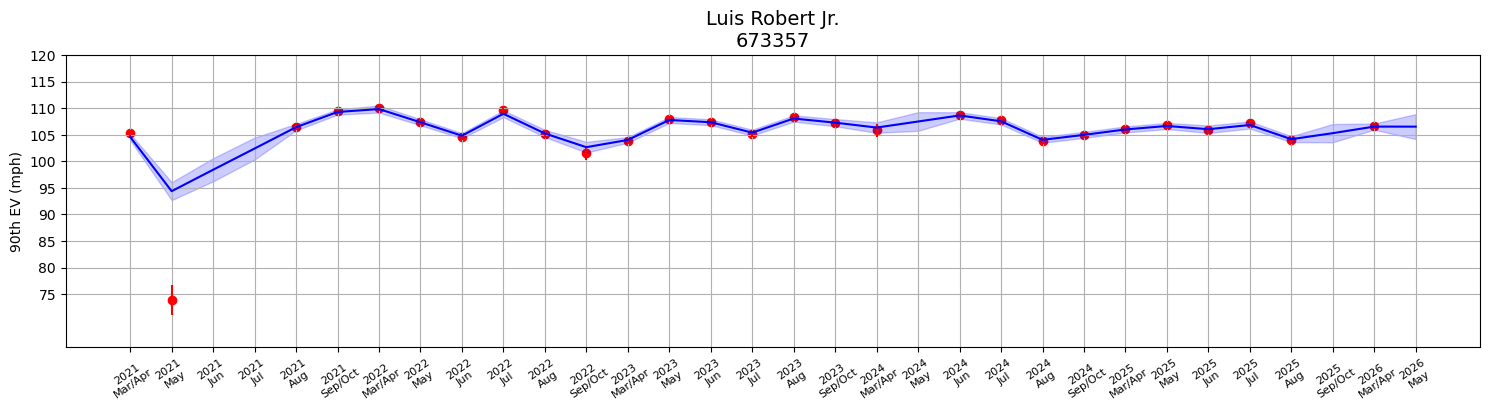

In [145]:
rando = random.choice(pd.unique(cdf['bam_id']))
plot_performance(cdf, rando)

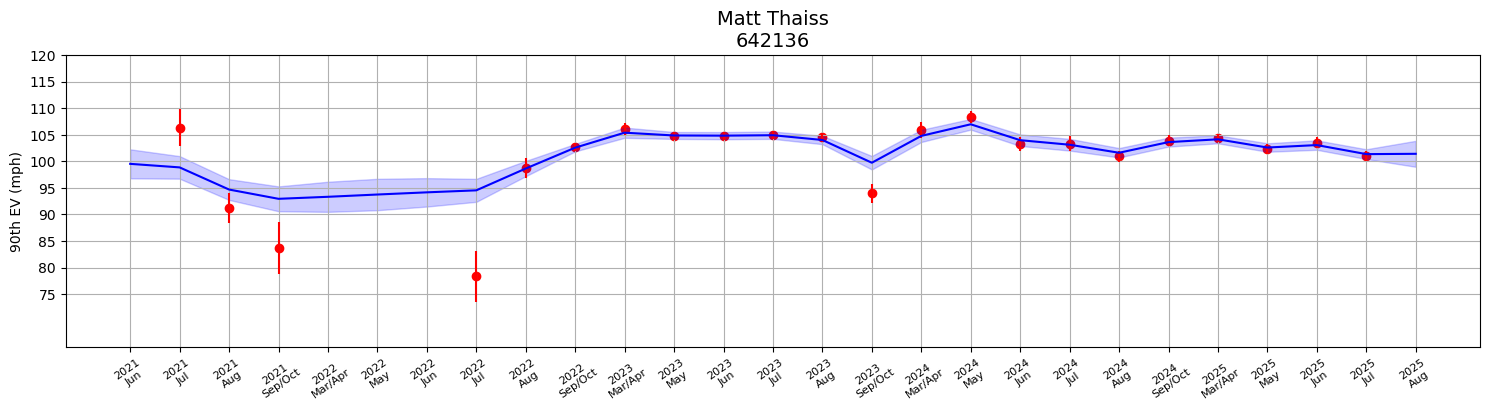

In [211]:
rbs = pd.unique(cdf.loc[cdf['bips']<10]['bam_id'])
rando = random.choice(rbs)
plot_performance(cdf, rando)

In [ ]:
# Alan Roden
# 677008 heston kjerstad
# 666176 jo adell
# 571912 luke maile
# 641933 tyler o'neil
# Garrett Stubbs 596117
# alec bohm 664761
# zach short 670097
# luke williams 663897
# matt thaiss 642136

In [ ]:
bat_speed_vals = df['bat_speed_obs'].values.astype(float)
swings_vals = df['swings'].fillna(0).values.astype(float)

swings_vals_observed = np.clip(swings_vals[bat_speed_vals_observed_idx], 1, 500)
sigma_bat_speed_observed = sigma_bat_speed / np.sqrt(swings_vals_observed)

bat_speed_obs_mask = ~np.isnan(bat_speed_vals) # mask missing bat speed values
bat_speed_vals_observed_idx = np.where(bat_speed_obs_mask)[0].astype("int32") # indices of observed bat speed values
bat_speed_vals_observed = bat_speed_vals[bat_speed_vals_observed_idx] # observed bat speed values

bat_speed_vals_missing_idx = np.where(~bat_speed_obs_mask)[0].astype("int32")
n_missing_bat_speed = len(bat_speed_vals_missing_idx)

mu_bat_speed = mu_emp[1]
sigma_bat_speed = sigma_emp[1]

In [ ]:
complete_mask = ~np.isnan(ev90_vals) & ~np.isnan(bat_speed_vals)
ev90_complete = ev90_vals[complete_mask]
bat_speed_complete = bat_speed_vals[complete_mask]

sigma_ev90_emp = ev90_complete.std()
sigma_bat_speed_emp = bat_speed_complete.std()

L00_emp = sigma_ev90_emp
L10_emp = corr_empirical * sigma_bat_speed_emp
L11_emp = sigma_bat_speed_emp * np.sqrt(1 - corr_empirical**2)
print(f"Empirical correlation: {corr_empirical:.3f}")
print(f"L00 (sigma_ev): {L00_emp:.3f}")
print(f"L10 (corr * sigma_bs): {L10_emp:.3f}")
print(f"L11 (residual sigma_bs): {L11_emp:.3f}")
print(f"L10/L00 (regression coef): {L10_emp/L00_emp:.3f}")

Empirical correlation: 0.502
L00 (sigma_ev): 4.738
L10 (rho * sigma_bs): 1.406
L11 (residual sigma_bs): 2.422
L10/L00 (regression coef): 0.297


In [ ]:
coords = {
    "obs_id": np.arange(len(df)),
    "ev90_obs_id": np.arange(len(ev90_vals_observed_idx)),
    "bat_speed_obs_id": np.arange(len(bat_speed_vals_observed_idx)),
    "bat_speed_missing_id": np.arange(n_missing_bat_speed),
    "time": time_list,
    "time_walk": time_list[1:],
    "player": player_name_list,
    "metric": ['ev90','bat_speed']
}

with pm.Model(coords=coords) as model:
    # data
    time_idx = pm.Data("time_idx", time_idx_vals, dims=("obs_id",))
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("obs_id",))
    ev90_idx_obs = pm.Data('ev90_idx_obs', ev90_vals_observed_idx, dims=("ev90_obs_id",))
    bat_speed_obs_idx = pm.Data('bat_speed_obs_idx', bat_speed_vals_observed_idx, dims=("bat_speed_obs_id",))

    # priors
    ## ev90 distribution
    ev90_distribution = pm.Normal('ev90_distribution', mu=mu_ev90, sigma=sigma_ev90)
    ## how much do we expect players to vary from the overall mean ev90 +/- 3*sigma
    sigma_player = pm.HalfNormal('sigma_player', sigma=10.0)
    ## month over month change in ev90
    sigma_month = pm.HalfNormal('sigma_month', sigma=10.0)
    
    # set initial values from N(0,1) dist
    player_init = pm.Normal('player_init', mu=0, sigma=1.0, dims=("player"))
    # player = u_pop + scale*init(0,1)
    player_start = pm.Deterministic('player_start', ev90_distribution + player_init * sigma_player, dims=("player"))
    
    # create matrix of size (n_months_years-1, n_players) of monthly innovations
    # one innovation per player per time step
    month_innovations = pm.Normal('month_innovations', mu=0, sigma=1.0, dims=("time_walk","player"))
    # [0, player],
    # [0+month_innovation_1, player],
    # [0+month_innovation_1+month_innovation_2, player], ...
    walk = pt.concatenate([
        pt.zeros((1, len(coords["player"]))),
        pt.cumsum(month_innovations, axis=0)
    ], axis=0)

    # scale the walk by innovation variance
    monthly_walk = pm.Deterministic('monthly_walk', walk*sigma_month, dims=("time","player"))

    # make player start "first index", then add walk to get innovations over the months
    # [ev90 (from ev90 dist) in month 0, player]
    # [ev90 (from ev90 dist + month_innovation_1), player], ...
    # [ev90 (from ev90 dist + month_innovation_1 + month_innovation_2), player], ...
    theta_ev90 = pm.Deterministic('theta_ev90', player_start[None, :] + monthly_walk, dims=("time","player"))
    theta_ev90_obs = theta_ev90[time_idx, player_idx]

    # lkhood
    pm.Normal('ev90_lkhood', mu=theta_ev90_obs[ev90_idx_obs], sigma=sigma_ev90_observed, observed=ev90_vals_observed, dims=("ev90_obs_id",))

    # missing data imputation
    bat_speed_distribution = pm.Normal('bat_speed_distribution', mu=mu_bat_speed, sigma=sigma_bat_speed)
    chol, corr, stds = pm.LKJCholeskyCov("chol", n=2, eta=2.0,
                                        sd_dist=pm.HalfNormal.dist(
                                            sigma=np.array([sigma_ev90_emp, sigma_bs_emp]),
                                            shape=2
                                            )
                                        )
    # rip chol components
    l00 = chol[0, 0]
    l10 = chol[1, 0]
    l11 = chol[1, 1]

    # mvn cond dist for p(bat_speed | ev90)
    # E[bat_speed | ev90] = mu_bat_speed + (l10/l00) * (theta_ev90_obs - ev90_distribution)
    # V(bat_speed | ev90) = l11^2
    bat_speed_cond_mu_miss = bat_speed_distribution + (l10/l00) * (theta_ev90_obs[bat_speed_vals_missing_idx] - ev90_distribution)
    true_bat_speed_missing = pm.Normal("true_bat_speed_missing", mu = bat_speed_cond_mu_miss, sigma = l11, dims = "bat_speed_missing_id")
    # tease out the observed for the likelihood
    bat_speed_cond_mu_obs = bat_speed_distribution + (l10/l00) * (theta_ev90_obs[bat_speed_obs_idx] - ev90_distribution)

    # lkhood for bat speed for observed data points
    pm.Normal('bat_speed_lkhood', mu=bat_speed_cond_mu_obs, sigma=pt.sqrt(l11**2 + sigma_bat_speed_observed**2), observed=bat_speed_vals_observed, dims=("bat_speed_obs_id",))


In [ ]:
trace = sample(model, draws = 1000, tune = 2000, target_accept = 0.99, path='mvn.nc',
            initvals = {"chol_cov_cholesky-cov-packed__": np.array([L00_emp, L10_emp, L11_emp])}
            )

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

There were 753 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [224]:
az.summary(trace, var_names=['ev90_distribution','sigma_player','sigma_month','bat_speed_distribution','chol'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ev90_distribution,102.926,0.577,102.392,103.905,0.282,0.156,7.0,28.0,1.83
sigma_player,2.725,1.576,0.000,3.799,0.784,0.451,6.0,25.0,2.18
sigma_month,1.589,0.918,0.000,2.144,0.457,0.264,7.0,20.0,1.61
bat_speed_distribution,70.339,0.319,70.030,70.876,0.155,0.084,7.0,26.0,2.03
chol[0],1.043,0.969,0.000,2.722,0.357,0.028,6.0,27.0,1.79
chol[1],-3.931,8.288,-18.262,1.651,4.123,2.373,6.0,11.0,1.87
chol[2],2.707,1.596,1.759,5.473,0.795,0.459,6.0,12.0,2.14


In [ ]:
# trace checks
# compute log_lkhood for comps
# eval the observed instances